In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report, hamming_loss, accuracy_score, multilabel_confusion_matrix)

In [6]:
data, meta = arff.loadarff('yeast.arff')

df = pd.DataFrame(data)
print(df.head())

       Att1      Att2      Att3      Att4      Att5      Att6      Att7  \
0  0.004168 -0.170975 -0.156748 -0.142151  0.058781  0.026851  0.197719   
1 -0.103956  0.011879 -0.098986 -0.054501 -0.007970  0.049113 -0.030580   
2  0.509949  0.401709  0.293799  0.087714  0.011686 -0.006411 -0.006255   
3  0.119092  0.004412 -0.002262  0.072254  0.044512 -0.051467  0.074686   
4  0.042037  0.007054 -0.069483  0.081015 -0.048207  0.089446 -0.004947   

       Att8      Att9     Att10  ...    Class5    Class6    Class7    Class8  \
0  0.041850  0.066938 -0.056617  ...  b'FALSE'  b'FALSE'   b'TRUE'   b'TRUE'   
1 -0.077933 -0.080529 -0.016267  ...  b'FALSE'  b'FALSE'  b'FALSE'  b'FALSE'   
2  0.013646 -0.040666 -0.024447  ...  b'FALSE'  b'FALSE'  b'FALSE'  b'FALSE'   
3 -0.007670  0.079438  0.062184  ...  b'FALSE'  b'FALSE'  b'FALSE'  b'FALSE'   
4  0.064456 -0.133387  0.068878  ...   b'TRUE'   b'TRUE'  b'FALSE'  b'FALSE'   

     Class9   Class10   Class11   Class12   Class13   Class14  
0  b

In [7]:
for col in df.columns:
    
    if df[col].dtype == object:
        df[col] = df[col].str.decode('utf-8')

print(df.head())

       Att1      Att2      Att3      Att4      Att5      Att6      Att7  \
0  0.004168 -0.170975 -0.156748 -0.142151  0.058781  0.026851  0.197719   
1 -0.103956  0.011879 -0.098986 -0.054501 -0.007970  0.049113 -0.030580   
2  0.509949  0.401709  0.293799  0.087714  0.011686 -0.006411 -0.006255   
3  0.119092  0.004412 -0.002262  0.072254  0.044512 -0.051467  0.074686   
4  0.042037  0.007054 -0.069483  0.081015 -0.048207  0.089446 -0.004947   

       Att8      Att9     Att10  ...  Class5  Class6  Class7  Class8  Class9  \
0  0.041850  0.066938 -0.056617  ...   FALSE   FALSE    TRUE    TRUE   FALSE   
1 -0.077933 -0.080529 -0.016267  ...   FALSE   FALSE   FALSE   FALSE   FALSE   
2  0.013646 -0.040666 -0.024447  ...   FALSE   FALSE   FALSE   FALSE   FALSE   
3 -0.007670  0.079438  0.062184  ...   FALSE   FALSE   FALSE   FALSE   FALSE   
4  0.064456 -0.133387  0.068878  ...    TRUE    TRUE   FALSE   FALSE   FALSE   

   Class10  Class11  Class12  Class13  Class14  
0    FALSE    FALSE

In [8]:
X = df.iloc[:, :-1]
y = pd.get_dummies(df.iloc[:, -1])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2417, 116)
Target Shape: (2417, 2)


In [9]:
print(X.info())

print("\nTarget Labels:")
print(y.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2417 entries, 0 to 2416
Columns: 116 entries, Att1 to Class13
dtypes: float64(103), object(13)
memory usage: 2.1+ MB
None

Target Labels:
Index(['FALSE', 'TRUE'], dtype='object')


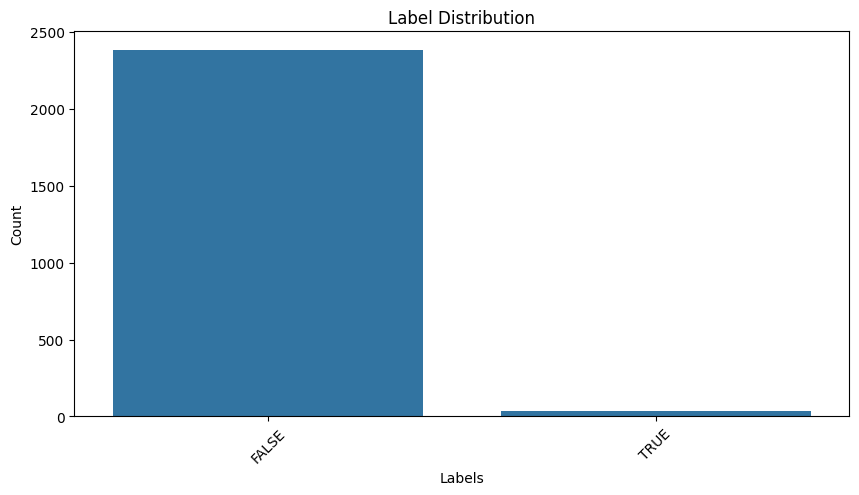

In [10]:
plt.figure(figsize=(10,5))

label_counts = y.sum().sort_values(ascending=False)

sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title("Label Distribution")
plt.xlabel("Labels")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

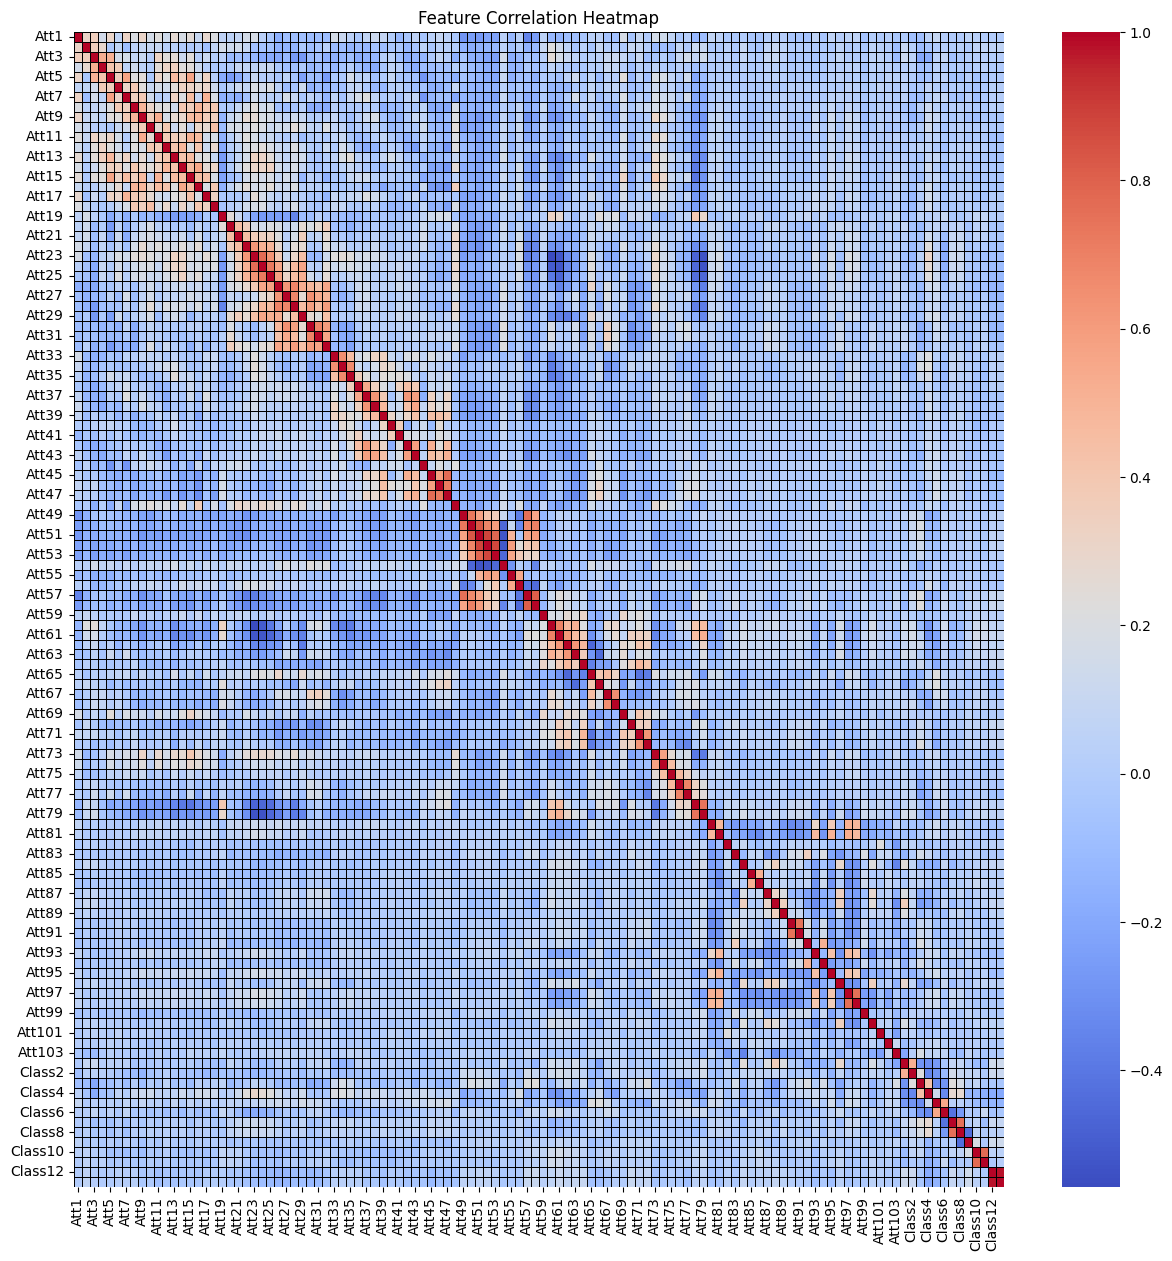

In [30]:
X_numeric = X.copy()

for col in X_numeric.columns:
    if X_numeric[col].dtype == object:
        X_numeric[col] = pd.factorize(X_numeric[col])[0]

plt.figure(figsize=(15,15))
sns.heatmap(
    X_numeric.corr(),
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1933, 116)
(484, 116)


In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    )
)

print(model)

MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       n_estimators=200,
                                                       random_state=42))


In [15]:
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [16]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[[ True False]
 [ True False]
 [ True False]
 [ True False]
 [ True False]]


In [17]:
print("Hamming Loss:")
print(hamming_loss(y_test, y_pred))

print("\nSubset Accuracy:")
print(accuracy_score(y_test, y_pred))

Hamming Loss:
0.014462809917355372

Subset Accuracy:
0.9855371900826446


In [18]:
print(classification_report(
        y_test,
        y_pred,
        zero_division=1
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       477
           1       1.00      0.00      0.00         7

   micro avg       0.99      0.99      0.99       484
   macro avg       0.99      0.50      0.50       484
weighted avg       0.99      0.99      0.98       484
 samples avg       0.99      0.99      0.99       484



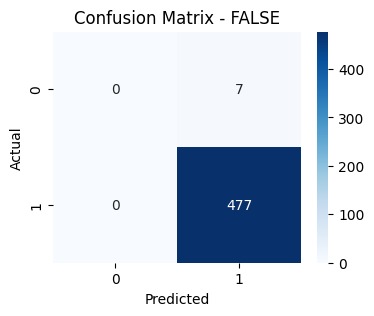

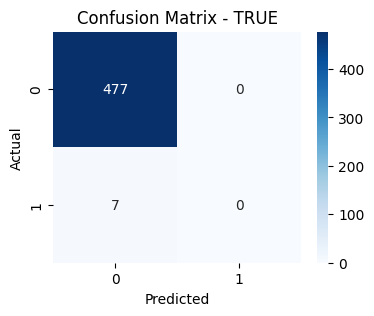

In [19]:
mcm = multilabel_confusion_matrix(
    y_test,
    y_pred
)

for i, matrix in enumerate(mcm):
    plt.figure(figsize=(4,3))
    sns.heatmap(matrix,
                annot=True,
                fmt='d',
                cmap='Blues'
    )

    plt.title(
        f'Confusion Matrix - {y.columns[i]}'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [20]:
rf_model = model.estimators_[0]
importances = rf_model.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X_numeric.columns
).sort_values(ascending=False)

print(feature_importance)

Class4     0.126122
Class3     0.091437
Att91      0.030007
Class2     0.029377
Att50      0.025851
             ...   
Class10    0.000479
Class11    0.000249
Class13    0.000117
Class12    0.000023
Class9     0.000016
Length: 116, dtype: float64


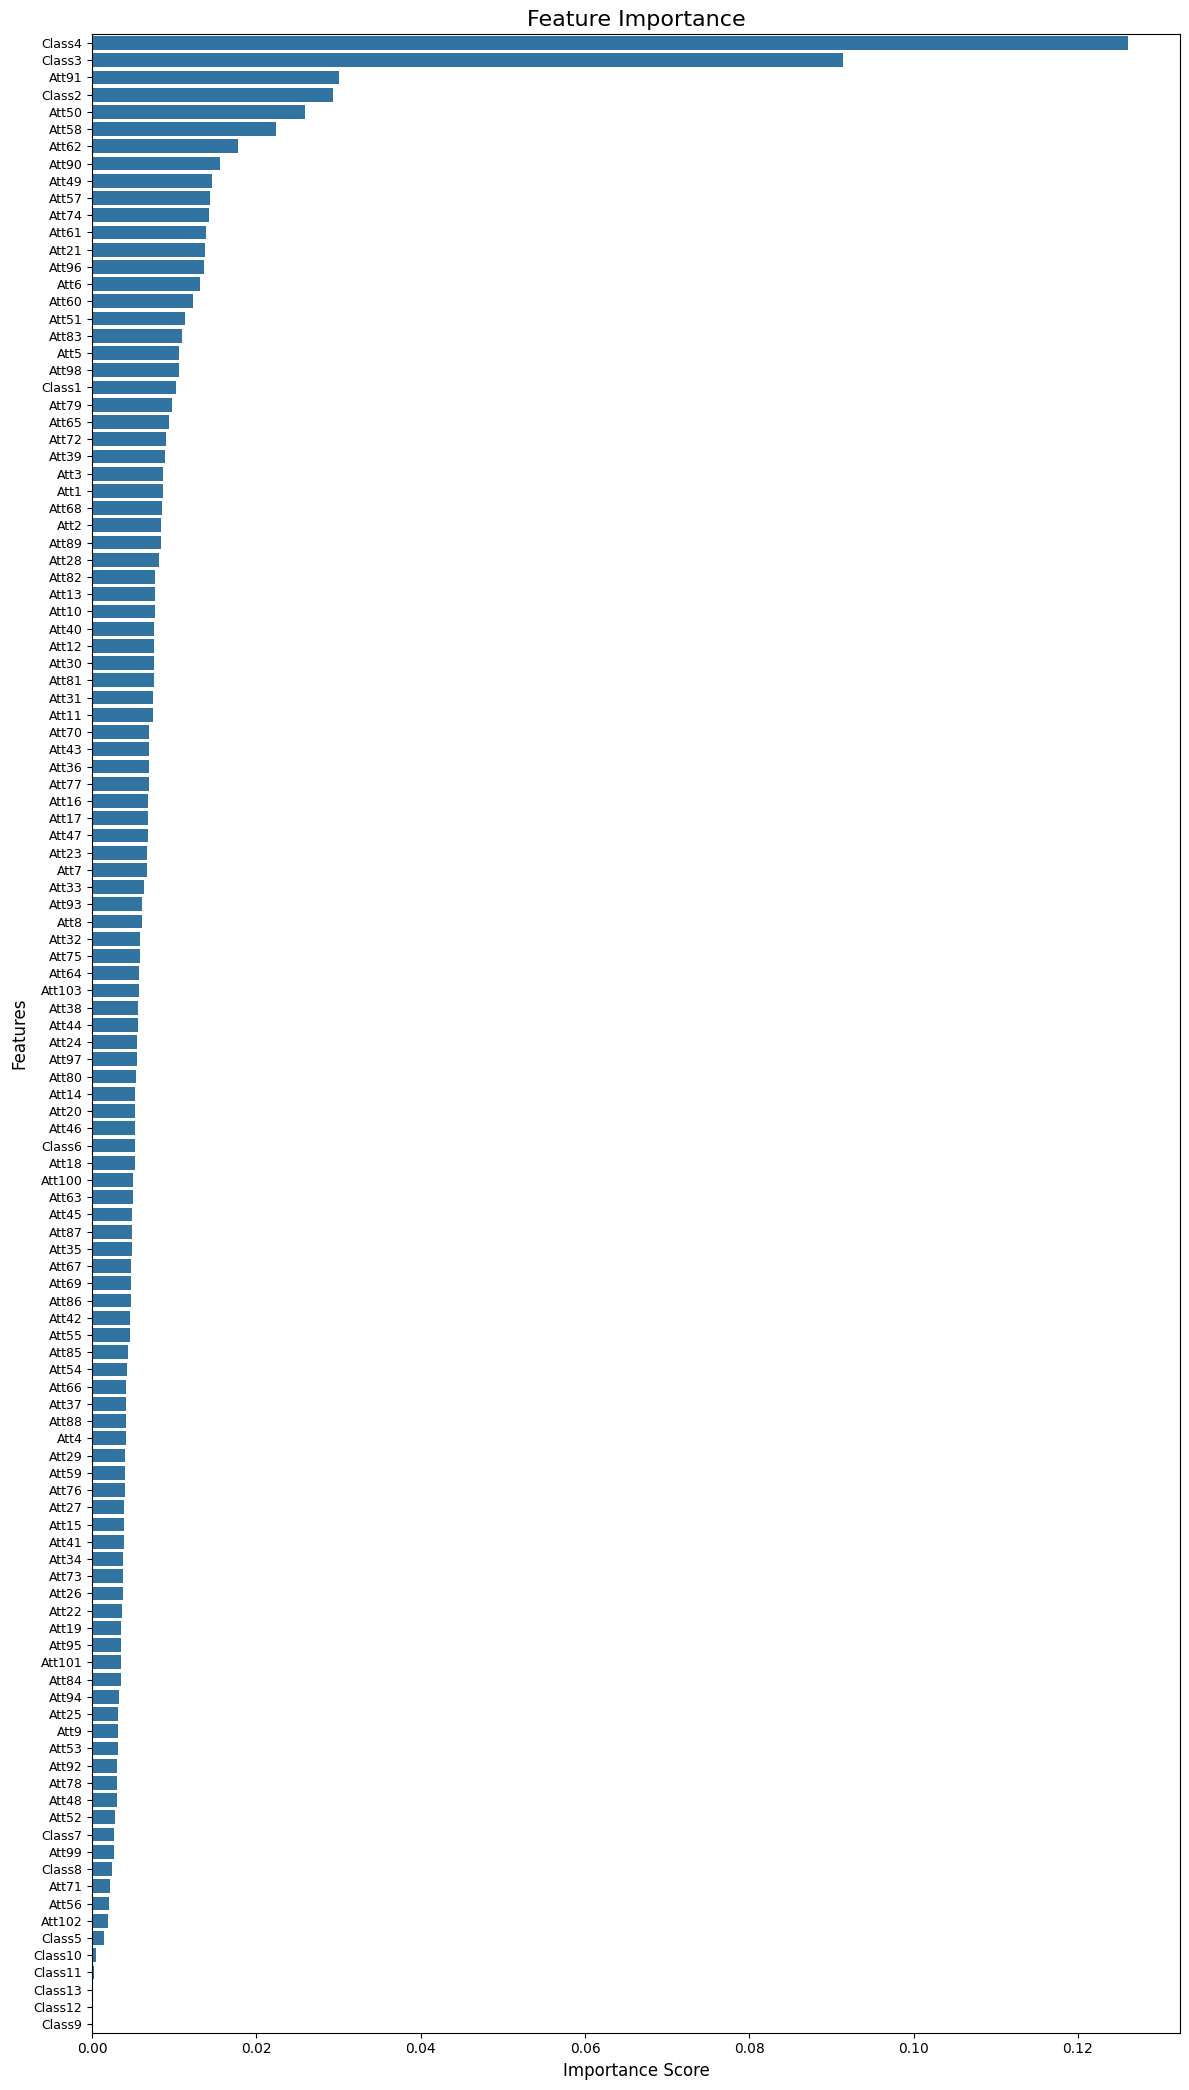

In [27]:
plt.figure(figsize=(12,21))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title("Feature Importance", fontsize=16)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.yticks(fontsize=9)

plt.tight_layout()

plt.show()